In [30]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sn

import warnings
warnings.filterwarnings('ignore')

In [47]:
plt.rcParams['figure.figsize'] = (15,6)

> Point-wise anomaly detection

> Pattern-wise anomaly detection

In [31]:
df = pd.read_csv('../data_analysis/sources/ec2_cpu_utilization.csv')
df.head()

,timestamp,value
0,2014-02-14 14:30:00,0.132
1,2014-02-14 14:35:00,0.134
2,2014-02-14 14:40:00,0.134
3,2014-02-14 14:45:00,0.134
4,2014-02-14 14:50:00,0.134


In [32]:
df.shape

(4032, 2)

In [33]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
value,4032.0,0.126303,0.094813,0.066,0.132,0.134,0.134,2.344


In [35]:
anomalies_timestamp = [
    '2014-02-26 22:05:00',
    '2014-02-27 17:15:00'
]

In [39]:
df['is_anomaly'] = 1

for each in anomalies_timestamp:
    df.loc[df['timestamp'] == each, 'is_anomaly'] = -1


In [43]:
anomaly_df = df[df["is_anomaly"] == -1]
inlier_df = df[df['is_anomaly'] == 1]



<Axes: xlabel='timestamp', ylabel='value'>

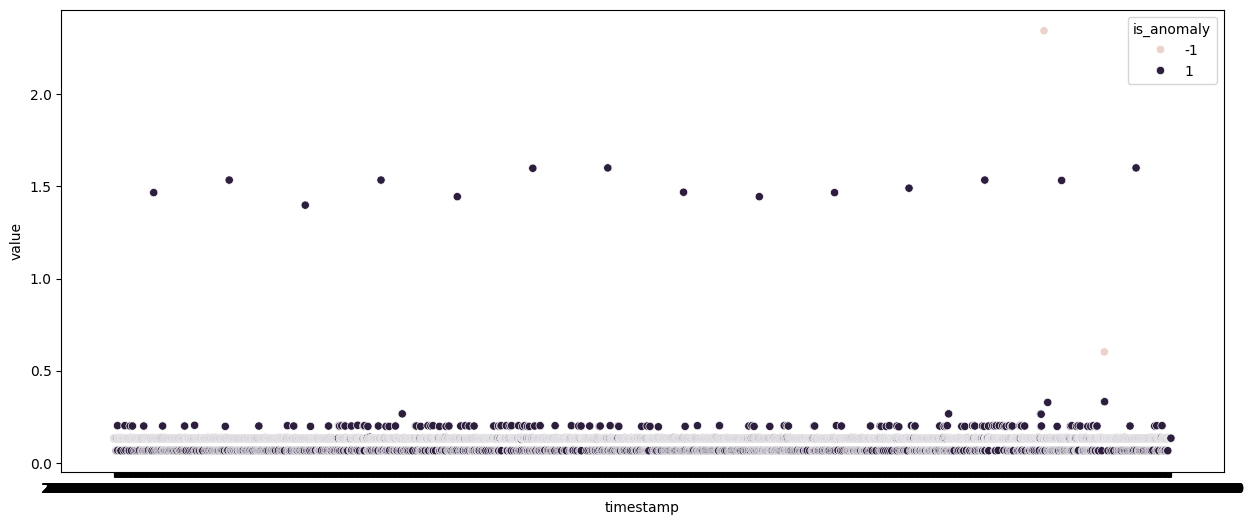

In [54]:
sn.scatterplot(x=df.timestamp, y=df.value, hue=df.is_anomaly)

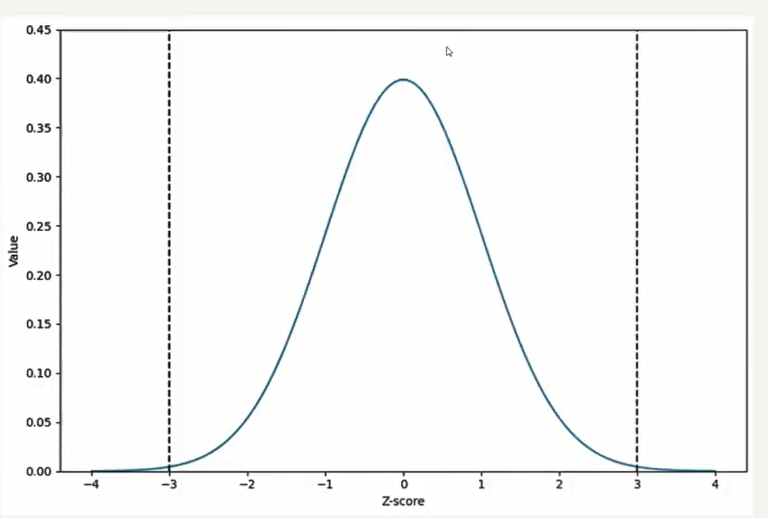

In [ ]:
#MAD -> Mean absolute deviation

# z = (x - mean) / std

#! The presence of outliers affect the mean, and therefore there z-score

#! Robust z-score method that uses the median instead of mean

# So < -3 and 3 < are outliers 

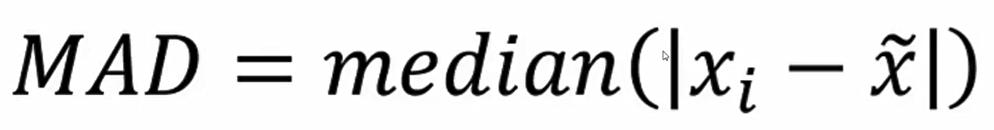

In [58]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
value,4032.0,0.126303,0.094813,0.066,0.132,0.134,0.134,2.344
is_anomaly,4032.0,0.999008,0.044538,-1.000,1.000,1.000,1.000,1.000


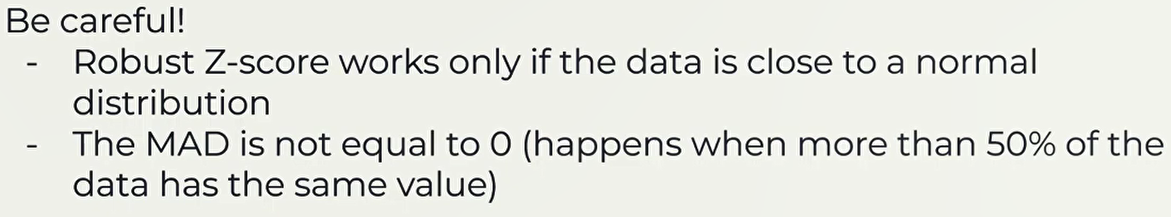